<a href="https://colab.research.google.com/github/aakashkumar089/Class-notes/blob/main/OTS_Regularisation_AD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures

In [2]:
df = pd.read_csv('/content/Advertising.csv')

In [3]:
# X = df.drop()
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [4]:
X = df.drop('sales',axis=1)
y = df['sales']

In [5]:
X.head()

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [6]:
y.head()

,sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9


In [7]:
Polynomial_Covert = PolynomialFeatures(degree=4, include_bias=False)

In [8]:
polynial_features=Polynomial_Covert.fit_transform(X)

In [9]:
polynial_features

array([[2.30100000e+02, 3.78000000e+01, 6.92000000e+01, ...,
        6.84220038e+06, 1.25259330e+07, 2.29310730e+07],
       [4.45000000e+01, 3.93000000e+01, 4.51000000e+01, ...,
        3.14150810e+06, 3.60514034e+06, 4.13719668e+06],
       [1.72000000e+01, 4.59000000e+01, 6.93000000e+01, ...,
        1.01179340e+07, 1.52760964e+07, 2.30639102e+07],
       ...,
       [1.77000000e+02, 9.30000000e+00, 6.40000000e+00, ...,
        3.54263040e+03, 2.43793920e+03, 1.67772160e+03],
       [2.83600000e+02, 4.20000000e+01, 6.62000000e+01, ...,
        7.73062416e+06, 1.21849362e+07, 1.92057804e+07],
       [2.32100000e+02, 8.60000000e+00, 8.70000000e+00, ...,
        5.59803240e+03, 5.66312580e+03, 5.72897610e+03]])

In [10]:
#Train Test Split
from sklearn.model_selection import train_test_split


X_train,X_test,y_train,y_test = train_test_split(polynial_features,y,test_size = 0.30 , random_state=42)

In [11]:
# Scaling the Data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [12]:
scaler.fit(X_train)

StandardScaler()

In [13]:
X_train = scaler.transform(X_train)

In [14]:
X_train

array([[ 1.53003874, -0.8862929 , -1.16598019, ..., -0.57611212,
        -0.48601319, -0.40624986],
       [ 0.34103865, -0.17314426, -0.40960132, ..., -0.49290326,
        -0.43954349, -0.38491449],
       [-0.5202089 , -0.42000341,  0.39526337, ..., -0.39821381,
        -0.27601439, -0.20275565],
       ...,
       [ 0.73338476,  0.68400555,  1.38437419, ...,  0.97854267,
         0.96122048,  0.70517242],
       [ 0.11017646, -0.92743609, -0.62293895, ..., -0.56560402,
        -0.4751256 , -0.39760176],
       [ 1.48099548, -0.9205789 , -0.43869282, ..., -0.55933253,
        -0.46576856, -0.3871646 ]])

In [15]:
X_test = scaler.transform(X_test)

In [16]:
X_test

array([[ 0.08266439,  0.55371878,  1.08861066, ...,  0.53541975,
         0.49779243,  0.31197564],
       [ 0.46663725,  1.65772773,  1.08861066, ...,  1.95893681,
         0.99933309,  0.31197564],
       [ 1.63290998,  0.32743123,  0.61829816, ...,  0.0175691 ,
        -0.00647667, -0.08690722],
       ...,
       [ 1.59463231,  1.28743902,  1.00618476, ...,  1.29089766,
         0.70811484,  0.22398872],
       [-1.63624219, -0.23485905, -0.65203044, ..., -0.53142553,
        -0.46581742, -0.39874204],
       [ 0.49295315, -1.373154  , -1.1902231 , ..., -0.5777759 ,
        -0.48644666, -0.40629261]])

In [17]:
# Ridge regression

from sklearn.linear_model import Ridge

In [18]:
ridge_model = Ridge(alpha=8)


In [19]:
ridge_model.fit(X_train,y_train)

Ridge(alpha=8)

In [20]:
test_prediction = ridge_model.predict(X_test)

In [21]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error

In [22]:
MAE = mean_absolute_error(y_test,test_prediction)
print(MAE)

0.6734804446090551


In [23]:
MSE = mean_squared_error(y_test,test_prediction)
print(MSE)

0.7677005221610405


In [24]:
RMSE = root_mean_squared_error(y_test,test_prediction)
print(RMSE)

0.8761852099647884


In [25]:
# Cross validation
from sklearn.linear_model import RidgeCV

In [26]:
# help(RidgeCV)

In [27]:
ridge_cv_model = RidgeCV(alphas=(0.1,1.0,5,10,15),scoring='neg_mean_absolute_error')

In [28]:
ridge_cv_model.fit(X_train,y_train)

RidgeCV(alphas=(0.1, 1.0, 5, 10, 15), scoring='neg_mean_absolute_error')

In [29]:
ridge_cv_model.alpha_

np.float64(0.1)

In [30]:
test_predictions = ridge_cv_model.predict(X_test)

In [31]:
MAE = mean_absolute_error(y_test,test_predictions)
print(MAE)

0.4334792652366912


In [32]:
MSE = mean_squared_error(y_test,test_predictions)
print(MSE)

0.3354375145983139


In [33]:
RMSE = root_mean_squared_error(y_test,test_prediction)
print(RMSE)

0.8761852099647884


In [34]:
ridge_cv_model.coef_

array([ 5.61095821,  0.46984961,  0.62172902, -4.4097419 ,  3.59267055,
       -0.69880063,  0.118551  ,  0.12062932, -0.44841747, -0.65020411,
       -1.34833143, -0.73201324,  1.23899218, -0.28246039,  0.76183027,
       -0.3026452 ,  0.28639364, -0.55893568,  0.43651496,  1.29956745,
        1.3212358 ,  0.72321437, -1.67450561,  0.82829332, -0.02221266,
        0.98563417, -0.87060813, -0.16302684, -0.33563442, -0.41759971,
        0.25072712,  0.09538363,  0.39773753, -0.33982769])

## Ridge regression
### 1. Does a panalty to the cofficients of the features and decrese the influence of that feature.


##Lasso Regression
### 1. Regression can shrink coefficients to zero , performing feature selection

## Feature selection ?
### Selecting the most important feature without any  overlapping

In [35]:
# Lasso Rigression
from sklearn.linear_model import LassoCV

In [36]:
Lasso_cv_model = LassoCV(eps=0.1,n_alphas=100,cv = 5)

In [37]:
print(Lasso_cv_model)

LassoCV(cv=5, eps=0.1)


In [38]:
Lasso_cv_model.fit(X_train,y_train)

LassoCV(cv=5, eps=0.1)

In [39]:
Lasso_cv_model.alpha_

np.float64(0.4924531806474871)

In [40]:
test_predictions = Lasso_cv_model.predict(X_test)

In [41]:
y_test

,sales
95,16.9
15,22.4
30,21.4
158,7.3
128,24.7
115,12.6
69,22.3
170,8.4
174,11.5
45,14.9


In [42]:
test_predictions

array([16.18828395, 21.34601239, 21.29934674,  8.98109557, 23.33158486,
       12.24724834, 21.8224454 ,  9.59903169, 11.81581139, 14.92302962,
        9.60694075,  9.37296526, 12.00447845,  8.59678591, 10.31472809,
       11.86280504,  8.66918795, 15.94962639, 10.98512815, 18.6269507 ,
       19.55129872, 11.99294325, 10.55255733, 21.80738206,  9.89195191,
        9.09616359, 21.39645095, 12.29763622, 10.54978909,  8.70888316,
       11.27967285, 10.78741317, 21.96754542,  9.39454809, 16.11311822,
       20.52366553, 11.522109  , 20.63916064, 11.69798413,  8.71996314,
       10.73020927, 12.30844775, 10.17457171,  9.97838601, 11.58324862,
        8.95688059, 10.47153581, 14.11621893, 10.25560703, 11.65169317,
       13.46900461, 11.69011914,  8.93880205,  8.788024  ,  9.31097615,
       10.70786975, 10.64013287, 25.8204003 ,  9.02997622, 11.45183797])

In [43]:
MAE = mean_absolute_error(y_test,test_predictions)
print(MAE)

0.6811456342837985


In [44]:
MSE = mean_squared_error(y_test,test_predictions)
print(MSE)

1.0710443722690077


In [45]:
RMSE = root_mean_squared_error(y_test,test_prediction)
print(RMSE)

0.8761852099647884


In [46]:
Lasso_cv_model.coef_

array([0.97675148, 0.        , 0.        , 0.        , 3.8148913 ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        ])

In [47]:
print(Lasso_cv_model.intercept_)

14.497142857142858


In [48]:
# ElasticNet



## Elastic Net combines the panalties of ridgre regression and lasso in attempt  to get the best out of both.

In [64]:
from sklearn.linear_model import ElasticNet

from sklearn.linear_model import ElasticNetCV


*   ElasticNet--->	float_value-->	Train model

*   ElasticNetCV-->	list -->	Find best hyperparameter




In [65]:
# elastic_model = ElasticNet(l1_ratio=[.1,0.2,0.5,0.8,0.10,1.0],tol=0.01)

In [66]:
elastic_model = ElasticNetCV(
    l1_ratio=[0.1, 0.2, 0.5, 0.8, 1.0],
    tol=0.01,
    cv=5
)


In [68]:
elastic_model.fit(X_train,y_train)

ElasticNetCV(cv=5, l1_ratio=[0.1, 0.2, 0.5, 0.8, 1.0], tol=0.01)

In [69]:
elastic_model

ElasticNetCV(cv=5, l1_ratio=[0.1, 0.2, 0.5, 0.8, 1.0], tol=0.01)

In [70]:
elastic_model.l1_ratio

[0.1, 0.2, 0.5, 0.8, 1.0]

l1_ratio = 1 → Lasso (L1)

l1_ratio = 0 → Ridge (L2)

In [71]:
elastic_model.alpha_

np.float64(0.004924531806474871)

In [56]:
print(elastic_model.coef_)  # Some values will become 0

[ 3.95732248  1.30046451  0.18150064 -0.77147637  1.58615255 -0.45322692
 -0.20608975  0.13063519  0.02857449 -0.76461333  0.455742   -0.09587025
  0.70577456 -0.03328695  0.02334274 -0.38233157  0.13612975  0.
  0.00489752 -0.39096496 -0.1032108  -0.01028231  0.21759918  0.01827386
  0.13088941  0.41213838 -0.0415989   0.00416069  0.06326361 -0.21367866
  0.07581365  0.         -0.0451496  -0.        ]


In [57]:
print("Best l1_ratio:", elastic_model.l1_ratio_)
print("Best alpha:", elastic_model.alpha_)

Best l1_ratio: 1.0
Best alpha: 0.004924531806474871


In [58]:
y_pred = elastic_model.predict(X_test)

In [59]:
y_test

,sales
95,16.9
15,22.4
30,21.4
158,7.3
128,24.7
115,12.6
69,22.3
170,8.4
174,11.5
45,14.9


In [60]:
y_pred

array([17.1112397 , 22.78845181, 19.90731273,  8.34977191, 24.3856755 ,
       12.61891209, 22.82548134,  8.19825808, 12.43495336, 15.52888224,
        8.2846862 ,  7.85731641, 12.32439988,  7.01259955, 10.38820375,
       12.25979588,  7.59219912, 16.57615325, 10.6151154 , 18.96422035,
       20.16684189, 13.20887546,  9.70640441, 22.21129624,  8.73944943,
        7.25075252, 22.41944402, 12.59096378,  9.98908014,  6.98015325,
       11.88176874, 10.212896  , 23.56675526,  9.81520735, 15.07665175,
       21.05252374, 10.56401455, 19.94561042, 11.70427804,  6.07829327,
       10.53797596, 12.89784507,  9.56774556,  8.90893245, 12.19241627,
        6.73486819,  9.8852341 , 14.65759555,  9.81921378, 11.4151671 ,
       13.61088865, 12.17689387,  8.89150407,  8.23692579,  8.01035907,
       10.680249  ,  9.96772456, 25.38451783,  7.41496544, 12.18954045])

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)

MAE: 0.6981738983681673
MSE: 0.7173031555496109


In [62]:
from sklearn.linear_model import Ridge, Lasso

ridge = Ridge().fit(X_train, y_train)
lasso = Lasso().fit(X_train, y_train)

print("ElasticNet MSE:", mse)
print("Ridge MSE:", mean_squared_error(y_test, ridge.predict(X_test)))
print("Lasso MSE:", mean_squared_error(y_test, lasso.predict(X_test)))

ElasticNet MSE: 0.7173031555496109
Ridge MSE: 0.5257198771573618
Lasso MSE: 2.1981096143550536


ValueError: x and y must be the same size

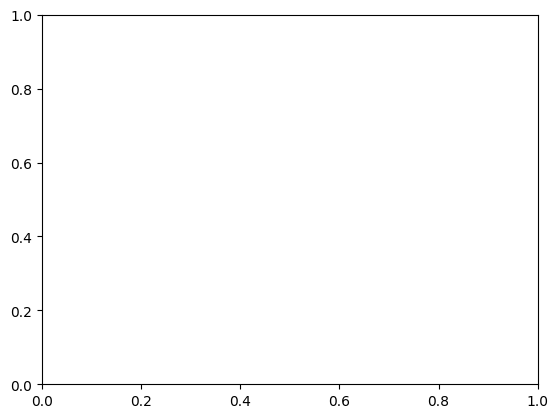

In [63]:
# Plot
plt.figure()
plt.scatter(X, y)
plt.plot(X_new, y_new)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Polynomial Regression (degree=4)")
plt.grid()
plt.show()

In [ ]:
X.shape

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns


plt.scatter(X[:,0], y)
sns.pairplot(df)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], y)